In [72]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

from sklearn.metrics import *

# importing

In [73]:
df = pd.read_csv(r"C:\Users\nagar\Downloads\Delivery_Logistics.csv")

In [82]:
df.shape

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  str    
 2   package_type         25000 non-null  str    
 3   vehicle_type         25000 non-null  str    
 4   delivery_mode        25000 non-null  str    
 5   region               25000 non-null  str    
 6   weather_condition    25000 non-null  str    
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  int64  
 10  expected_time_hours  25000 non-null  str    
 11  delayed              25000 non-null  str    
 12  delivery_status      25000 non-null  str    
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(2), str(9)
memory usage: 2

np.int64(0)

# CLEANING


In [83]:
df = df.drop_duplicates()

# Business Understanding

In [84]:
#Delay Rate
df["delayed"].value_counts(normalize=True)

delayed
no     0.73324
yes    0.26676
Name: proportion, dtype: float64

In [85]:
print(df["delivery_time_hours"].head())
print(df["expected_time_hours"].head())

0     8
1     2
2    10
3     6
4     9
Name: delivery_time_hours, dtype: int64
0    1970-01-01 00:00:00.000000008
1    1970-01-01 00:00:00.000000003
2    1970-01-01 00:00:00.000000016
3    1970-01-01 00:00:00.000000008
4    1970-01-01 00:00:00.000000016
Name: expected_time_hours, dtype: str


In [86]:
#Partner Distribution
df["delivery_partner"].value_counts()

delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

In [87]:
#Weather Distribution
df["weather_condition"].value_counts()

weather_condition
foggy     4219
stormy    4198
rainy     4171
cold      4158
hot       4130
clear     4124
Name: count, dtype: int64

In [88]:
df["expected_time_hours"] = (
    pd.to_datetime(df["expected_time_hours"])
      .dt.nanosecond
)

In [89]:
df["delivery_time_hours"] = (
    pd.to_datetime(df["delivery_time_hours"])
      .dt.nanosecond
)

In [90]:
df["delivery_time_hours"] = (
    df["delivery_time_hours"]
    .astype(int)
)

df["expected_time_hours"] = (
    df["expected_time_hours"]
    .astype(int)
)

# FEATURE ENGINEERING

In [91]:
#Delay Hours
df["delay_Hours"] = (
    df["delivery_time_hours"]
    -
    df["expected_time_hours"]
)

In [92]:
df["delay_Hours"].describe()

count    25000.000000
mean        -6.859640
std          8.069482
min        -24.000000
25%        -14.000000
50%         -6.000000
75%          0.000000
max         12.000000
Name: delay_Hours, dtype: float64

In [122]:
print(df["delivery_time_hours"].describe())
print(df["expected_time_hours"].describe())

count    25000.000000
mean         6.248040
std          3.140935
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         19.000000
Name: delivery_time_hours, dtype: float64
count    25000.000000
mean        13.107680
std          7.559024
min          2.000000
25%          8.000000
50%          8.000000
75%         16.000000
max         24.000000
Name: expected_time_hours, dtype: float64


In [94]:
#Actual Delay
df["actual_delay_hours"] = (
    df["delay_Hours"]
    .clip(lower=0)
)

In [95]:
#Delay Severity
df["delay_severity"] = pd.cut(
    df["delay_Hours"],
    bins=[-999,0,2,6,999],
    labels=[
        "early",
        "slight_delay",
        "moderate_delay",
        "severe_delay"
    ]
)

In [96]:
#Cost Per KM
df["cost_per_km"] = (
    df["delivery_cost"]
    /
    df["distance_km"]
)

In [97]:
#Cost Per KG
df["cost_per_kg"] = (
    df["delivery_cost"]
    /
    df["package_weight_kg"]
)

In [98]:
#Heavy Package
df["heavy_package_flag"] = (
    df["package_weight_kg"] > 10
).astype(int)

In [99]:
#Long Distance
df["long_distance_flag"] = (
    df["distance_km"] > 100
).astype(int)

In [100]:
# Heavy Package
df["heavy_package_flag"] = (
    df["package_weight_kg"] > 10
).astype(int)

# Long Distance
df["long_distance_flag"] = (
    df["distance_km"] > 100
).astype(int)

# Required Speed
df["speed_required"] = (
    df["distance_km"]
    /
    df["expected_time_hours"]
)

# Load Effort
df["load_effort"] = (
    df["distance_km"]
    *
    df["package_weight_kg"]
)

# EDA

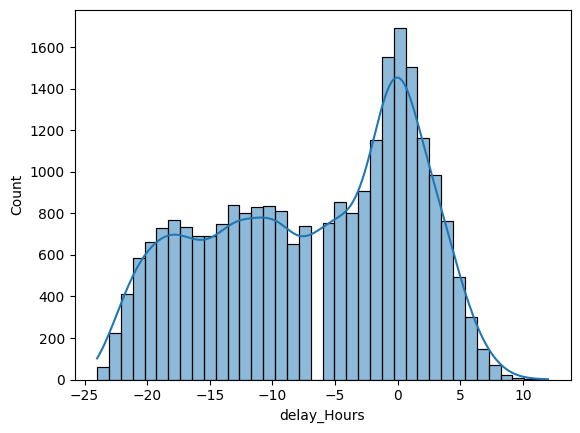

In [101]:
#Delay Distribution
sns.histplot(
    df["delay_Hours"],
    kde=True
)
plt.show()

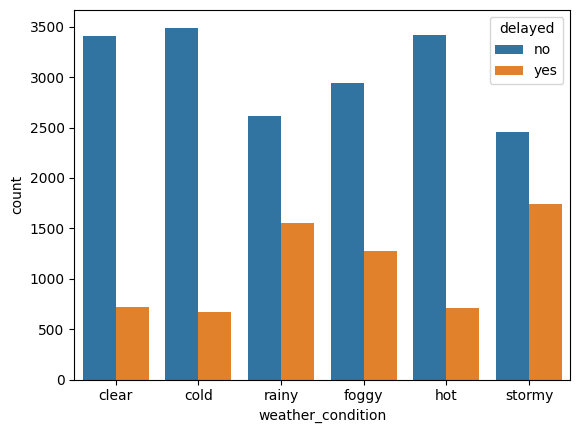

In [102]:
#Weather vs Delay
sns.countplot(
    x="weather_condition",
    hue="delayed",
    data=df
)
plt.show()

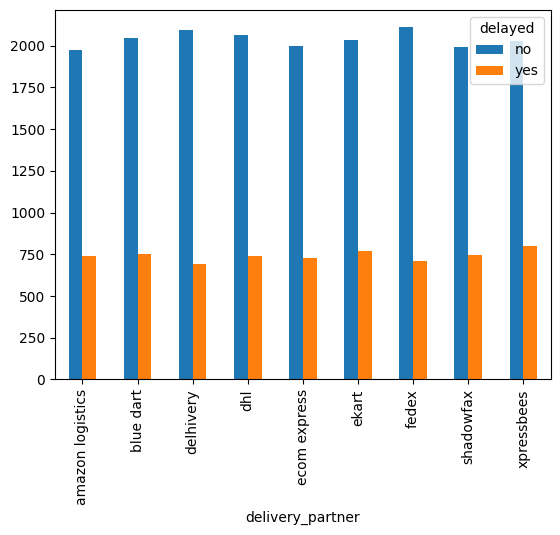

In [103]:
#Partner vs Delay
pd.crosstab(
    df["delivery_partner"],
    df["delayed"]
).plot(
    kind="bar"
)

plt.show()

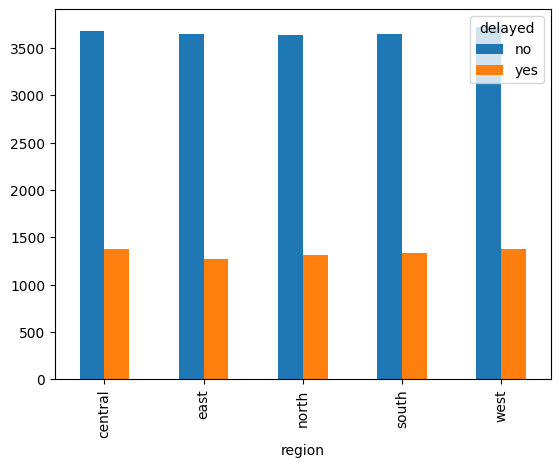

In [104]:
#Region vs Delay
pd.crosstab(
    df["region"],
    df["delayed"]
).plot(
    kind="bar"
)

plt.show()

# MODEL we will compare

In [148]:
features = [

    "delivery_partner",

    "package_type",

    "vehicle_type",

    "delivery_mode",

    "region",

    "weather_condition",

    "distance_km",

    "package_weight_kg",

    "expected_time_hours",

    "heavy_package_flag",

    "long_distance_flag",

    

    "load_effort"

]

In [149]:
models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    )
}

In [150]:
cat_cols = [

    "delivery_partner",

    "package_type",

    "vehicle_type",

    "delivery_mode",

    "region",

    "weather_condition"

]
num_cols = [

    "distance_km",

    "package_weight_kg",

    "expected_time_hours",

    "heavy_package_flag",

    "long_distance_flag",


    "load_effort"

]
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([

    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        cat_cols
    ),

    (
        "num",
        StandardScaler(),
        num_cols
    )

])

In [151]:
X = df[features]

y = (
    df["delayed"]
    .map({
        "no": 0,
        "yes": 1
    })
)


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [152]:
results = []

for name, model in models.items():

    pipe = Pipeline([

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            model
        )

    ])

    pipe.fit(
        X_train,
        y_train
    )

    y_pred = pipe.predict(
        X_test
    )

    y_prob = pipe.predict_proba(
        X_test
    )[:,1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([

        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc

    ])

In [153]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"

    ]
)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
1        Random Forest    0.8960   0.797515  0.817841  0.807550  0.965346
0  Logistic Regression    0.8936   0.794853  0.810345  0.802524  0.967195
2              XGBoost    0.8916   0.786127  0.815592  0.800589  0.964556


# Feature Importance Analysis

In [154]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [155]:
feature_names = (
    rf_pipe.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    rf_pipe.named_steps["classifier"]
    .feature_importances_
)

In [156]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print(
    importance_df.head(20)
)

                          Feature  Importance
41       num__expected_time_hours    0.202449
24     cat__delivery_mode_express    0.167295
39               num__distance_km    0.086718
44               num__load_effort    0.059623
26    cat__delivery_mode_standard    0.054329
27     cat__delivery_mode_two day    0.052616
40         num__package_weight_kg    0.052004
25    cat__delivery_mode_same day    0.033219
38  cat__weather_condition_stormy    0.028488
37   cat__weather_condition_rainy    0.018375
34    cat__weather_condition_cold    0.015569
36     cat__weather_condition_hot    0.015321
33   cat__weather_condition_clear    0.014923
43        num__long_distance_flag    0.013640
35   cat__weather_condition_foggy    0.009651
30              cat__region_north    0.006947
32               cat__region_west    0.006924
31              cat__region_south    0.006850
28            cat__region_central    0.006772
29               cat__region_east    0.006700


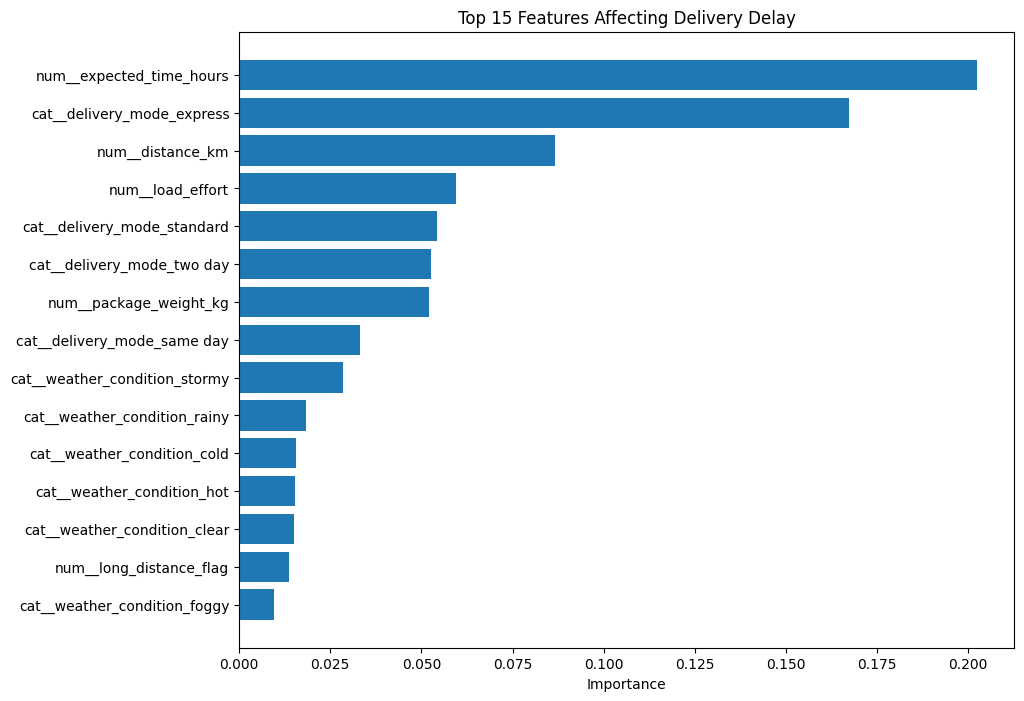

In [157]:
plt.figure(figsize=(10,8))

top_features = (
    importance_df
    .head(15)
    .sort_values(
        by="Importance"
    )
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Features Affecting Delivery Delay"
)

plt.xlabel(
    "Importance"
)

plt.show()

# Prob

In [158]:
partner_stats = (
    df.groupby("delivery_partner")
    .agg(
        delay_rate=("delayed",
                    lambda x: (x=="yes").mean()*100),

        avg_delay=("actual_delay_hours","mean"),

        avg_cost=("delivery_cost","mean")
    )
)

print(partner_stats.sort_values("delay_rate"))



                  delay_rate  avg_delay    avg_cost
delivery_partner                                   
delhivery          24.802584   0.604451  848.109810
fedex              25.159688   0.584457  857.355640
dhl                26.338330   0.654532  872.831125
ecom express       26.634827   0.648053  868.772186
blue dart          26.947820   0.657255  863.021705
amazon logistics   27.222427   0.640723  868.150131
shadowfax          27.302632   0.646199  868.340156
ekart              27.418779   0.652267  869.966720
xpressbees         28.273178   0.691437  868.165768


In [159]:
vehicle_stats = (
    df.groupby("vehicle_type")
    .agg(
        delay_rate=("delayed",
                    lambda x: (x=="yes").mean()*100),

        avg_delay=("actual_delay_hours","mean"),

        avg_cost=("delivery_cost","mean")
    )
)

print(vehicle_stats.sort_values("delay_rate"))

              delay_rate  avg_delay    avg_cost
vehicle_type                                   
scooter        26.137997   0.660278  862.914003
ev bike        26.434329   0.618540  869.235484
ev van         26.627794   0.628280  866.181463
van            26.773346   0.664676  857.658050
bike           27.043269   0.647596  868.917038
truck          27.044632   0.633534  864.768182


In [160]:
mode_stats = (
    df.groupby("delivery_mode")
    .agg(
        delay_rate=("delayed",
                    lambda x: (x=="yes").mean()*100),

        avg_delay=("actual_delay_hours","mean"),

        avg_cost=("delivery_cost","mean")
    )
)

print(mode_stats.sort_values("delay_rate"))

               delay_rate  avg_delay    avg_cost
delivery_mode                                   
standard         0.000000   0.000000  819.335575
two day          0.428435   0.001904  829.710800
same day        32.537028   0.613473  929.872468
express         73.784694   1.955720  880.426426


In [165]:
import pandas as pd

def shipment_analysis(
    delivery_partner,
    package_type,
    vehicle_type,
    delivery_mode,
    region,
    weather_condition,
    distance_km,
    package_weight_kg,
    expected_time_hours
):

    # ==========================
    # Feature Engineering
    # ==========================

    heavy_package_flag = int(
        package_weight_kg > 10
    )

    long_distance_flag = int(
        distance_km > 100
    )

    load_effort = (
        distance_km *
        package_weight_kg
    )

    # ==========================
    # Current Shipment
    # ==========================

    shipment = pd.DataFrame({

        "delivery_partner": [delivery_partner],
        "package_type": [package_type],
        "vehicle_type": [vehicle_type],
        "delivery_mode": [delivery_mode],
        "region": [region],
        "weather_condition": [weather_condition],
        "distance_km": [distance_km],
        "package_weight_kg": [package_weight_kg],
        "expected_time_hours": [expected_time_hours],
        "heavy_package_flag": [heavy_package_flag],
        "long_distance_flag": [long_distance_flag],
        "load_effort": [load_effort]

    })

    # ==========================
    # Prediction
    # ==========================

    probability = (
        rf_pipe
        .predict_proba(shipment)[0][1]
    )

    if probability < 0.30:
        risk = "LOW"

    elif probability < 0.60:
        risk = "MEDIUM"

    elif probability < 0.80:
        risk = "HIGH"

    else:
        risk = "CRITICAL"

    # ==========================
    # Delivery Mode Comparison
    # ==========================

    options = [

        ("standard", 24),
        ("two day", 16),
        ("same day", 8),
        ("express", 4)

    ]

    recommendations = []

    for mode, exp_time in options:

        temp = shipment.copy()

        temp["delivery_mode"] = mode
        temp["expected_time_hours"] = exp_time

        risk_prob = (
            rf_pipe
            .predict_proba(temp)[0][1]
        )

        if mode == "standard":

            speed_score = 25
            cost = distance_km * 1.0

        elif mode == "two day":

            speed_score = 50
            cost = distance_km * 1.3

        elif mode == "same day":

            speed_score = 75
            cost = distance_km * 1.8

        else:  # express

            speed_score = 100
            cost = distance_km * 2.5

        delay_risk = round(
            risk_prob * 100,
            2
        )

        decision_score = (

            0.60 * delay_risk +
            0.20 * cost +
            0.20 * (100 - speed_score)

        )

        recommendations.append({

            "Mode": mode,
            "Delay Risk %": delay_risk,
            "Cost ₹": round(cost, 2),
            "Speed Score": speed_score,
            "Decision Score": round(
                decision_score,
                2
            )

        })

    # ==========================
    # Recommendation Table
    # ==========================

    recommendation_df = pd.DataFrame(
        recommendations
    )

    recommendation_df = (
        recommendation_df
        .sort_values(
            by="Delay Risk %",
            ascending=True
        )
    )

    best_mode = (
        recommendation_df
        .iloc[0]["Mode"]
    )

    # ==========================
    # Output
    # ==========================

    print("=" * 60)
    print("SHIPMENT ANALYSIS")
    print("=" * 60)

    print(
        f"Delay Probability : {probability:.2%}"
    )

    print(
        f"Risk Level        : {risk}"
    )

    print()

    print(
        f"Recommended Mode  : {best_mode.upper()}"
    )

    print()

    print("All Options")

    print(
        recommendation_df
        .to_string(index=False)
    )

    print("=" * 60)

    return recommendation_df

In [166]:
shipment_analysis(

    delivery_partner="delhivery",

    package_type="electronics",

    vehicle_type="van",

    delivery_mode="express",

    region="west",

    weather_condition="rainy",

    distance_km=180,

    package_weight_kg=120,

    expected_time_hours=4

)

SHIPMENT ANALYSIS
Delay Probability : 87.50%
Risk Level        : CRITICAL

Recommended Mode  : STANDARD

All Options
    Mode  Delay Risk %  Cost ₹  Speed Score  Decision Score
standard           2.0   180.0           25            52.2
 two day          10.0   234.0           50            62.8
same day          78.0   324.0           75           116.6
 express          87.5   450.0          100           142.5


,Mode,Delay Risk %,Cost ₹,Speed Score,Decision Score
0,standard,2.0,180.0,25,52.2
1,two day,10.0,234.0,50,62.8
2,same day,78.0,324.0,75,116.6
3,express,87.5,450.0,100,142.5


In [167]:
df.to_csv("completed_file.csv")

In [168]:
print(
    df["delivery_id"]
    .duplicated()
    .sum()
)

498
